In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv
/kaggle/input/datasets/annapoorani13/weather/weather.ipynb


In [59]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv
/kaggle/input/datasets/annapoorani13/weather/weather.ipynb


In [60]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv
/kaggle/input/datasets/annapoorani13/weather/weather.ipynb


In [61]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv
/kaggle/input/datasets/annapoorani13/weather/weather.ipynb


# Weather Prediction Using Machine Learning

## Objective
The objective of this project is to analyze Seattle weather data and build machine learning models to predict weather conditions.

### Dataset Features
- date
- precipitation
- temp_max
- temp_min
- wind
- weather (Target Variable)

In [62]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv')

df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [63]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (1461, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [64]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [65]:
df.isnull().sum()


date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='weather', ylabel='count'>

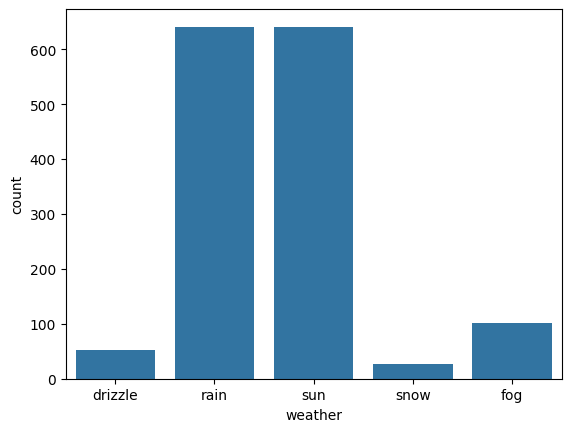

In [67]:
sns.countplot(
    x='weather',
    data=df
)

<Axes: xlabel='temp_max', ylabel='Count'>

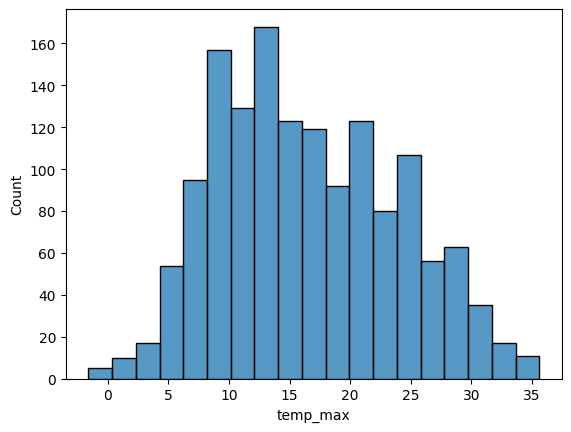

In [68]:
sns.histplot(df['temp_max'])

<Axes: ylabel='wind'>

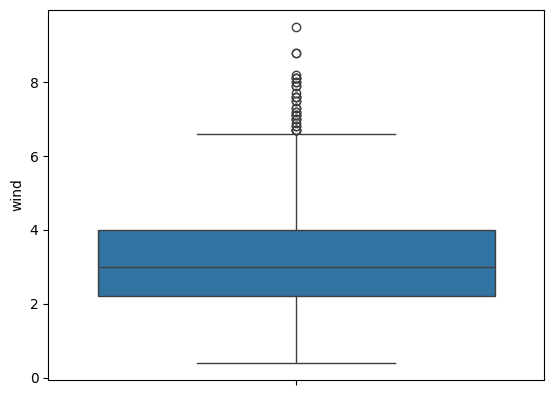

In [69]:
sns.boxplot(df['wind'])

In [70]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.head()

,precipitation,temp_max,temp_min,wind
0,0.0,12.8,5.0,4.7
1,10.9,10.6,2.8,4.5
2,0.8,11.7,7.2,2.3
3,20.3,12.2,5.6,4.7
4,1.3,8.9,2.8,6.1


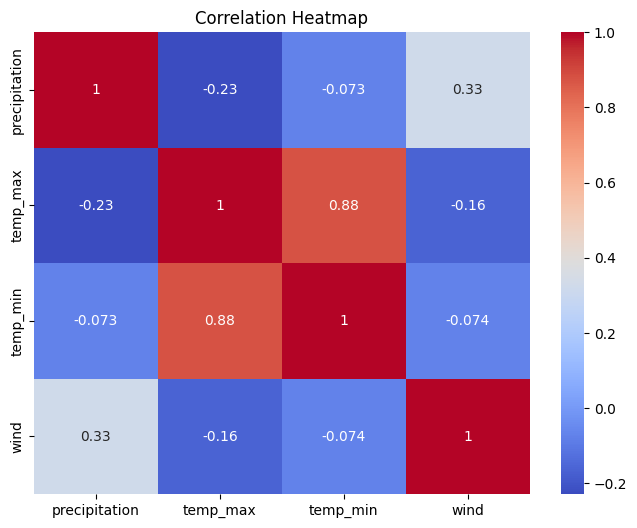

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- Maximum temperature and minimum temperature show a strong positive correlation (0.88).
- Precipitation has a weak negative correlation with maximum temperature (-0.23).
- Wind and precipitation have a moderate positive correlation (0.33).
- Most variables show weak correlations, indicating that each feature contributes unique information.

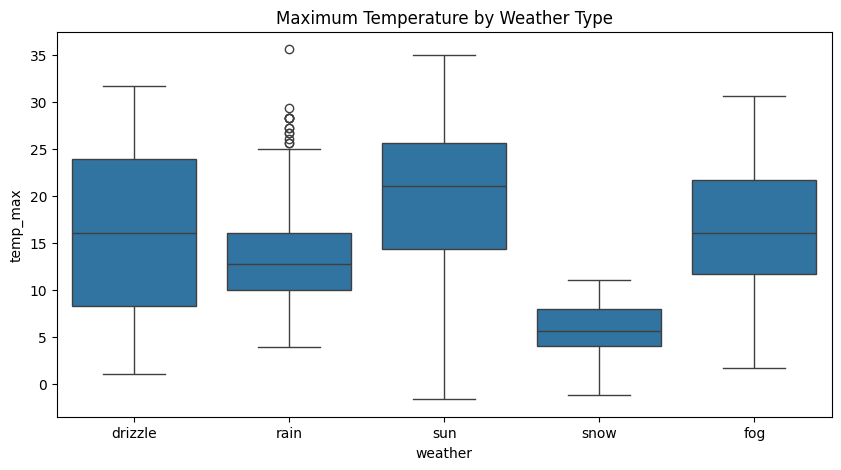

In [72]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='weather',
    y='temp_max',
    data=df
)

plt.title("Maximum Temperature by Weather Type")
plt.show()

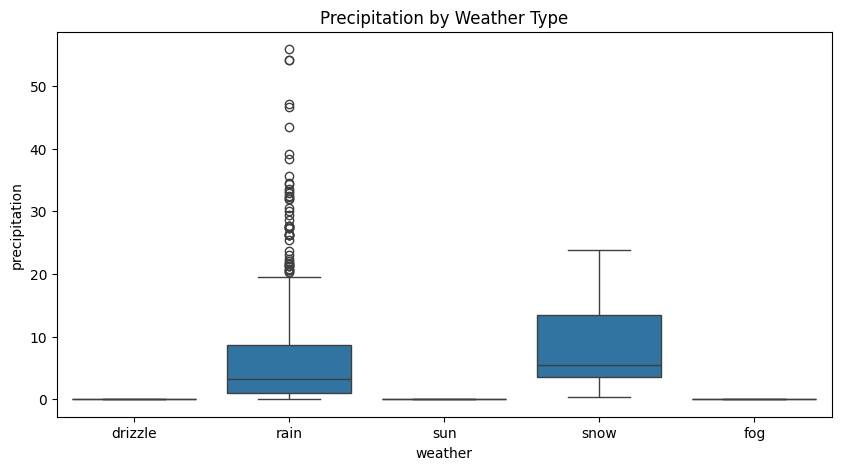

In [73]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='weather',
    y='precipitation',
    data=df
)

plt.title("Precipitation by Weather Type")
plt.show()

### Observation

- Sunny weather is associated with almost zero precipitation.
- Snow shows the highest median precipitation among all weather types.
- Rain exhibits a wide range of precipitation values and several extreme outliers.
- Fog and drizzle generally occur with low precipitation levels.
- Precipitation appears to be a strong predictor for distinguishing sunny, rainy, and snowy weather.

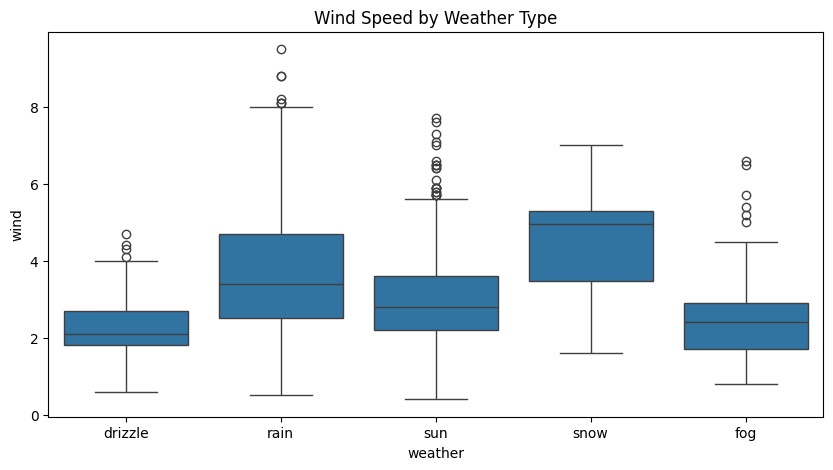

In [74]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='weather',
    y='wind',
    data=df
)

plt.title("Wind Speed by Weather Type")
plt.show()

In [75]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df['temp_diff'] = df['temp_max'] - df['temp_min']

df.head()

,date,precipitation,temp_max,temp_min,wind,weather,year,month,day,temp_diff
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,2012,1,1,7.8
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2012,1,2,7.8
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2012,1,3,4.5
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2012,1,4,6.6
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2012,1,5,6.1


### Observation

- Snowy weather generally exhibits the highest wind speeds.
- Rain shows a wide range of wind speeds and several extreme values.
- Drizzle is associated with relatively lower wind speeds.
- Significant overlap exists among weather categories, indicating that wind alone is insufficient for accurate weather classification.
- Wind contributes useful information but appears less discriminative than precipitation and temperature.

In [76]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['weather'] = le.fit_transform(df['weather'])

In [77]:
print(df.columns)

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather',
       'year', 'month', 'day', 'temp_diff'],
      dtype='object')


In [78]:
X = df.drop('weather', axis=1)

y = df['weather']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['weather'] = le.fit_transform(df['weather'])
for i, label in enumerate(le.classes_):
    print(i, "=", label)
    

0 = 0
1 = 1
2 = 2
3 = 3
4 = 4


In [80]:
X = df.drop('weather', axis=1)
y = df['weather']

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 9)
(293, 9)


In [82]:
X = df.drop("weather", axis=1)
y = df["weather"]

In [83]:
X = X.apply(pd.to_numeric, errors='coerce')

In [84]:
X = X.fillna(0)

In [85]:
print(X_train.dtypes)

date             datetime64[ns]
precipitation           float64
temp_max                float64
temp_min                float64
wind                    float64
year                      int32
month                     int32
day                       int32
temp_diff               float64
dtype: object


In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.78839590443686


The Logistic Regression model achieved an accuracy of 79.18% on the test dataset. The model was able to classify weather conditions reasonably well using precipitation, temperature, wind speed, and engineered features. Logistic Regression served as a baseline model for comparison with other machine learning algorithms.

In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.6723549488054608


K-Nearest Neighbors (KNN) was implemented for weather classification. The algorithm predicts weather conditions based on the majority class among the nearest neighboring observations. Feature scaling was applied before training because KNN relies on distance calculations. The model's performance was evaluated using accuracy metrics and compared with other machine learning algorithms.

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(
    y_test,
    pred_dt
)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8054607508532423


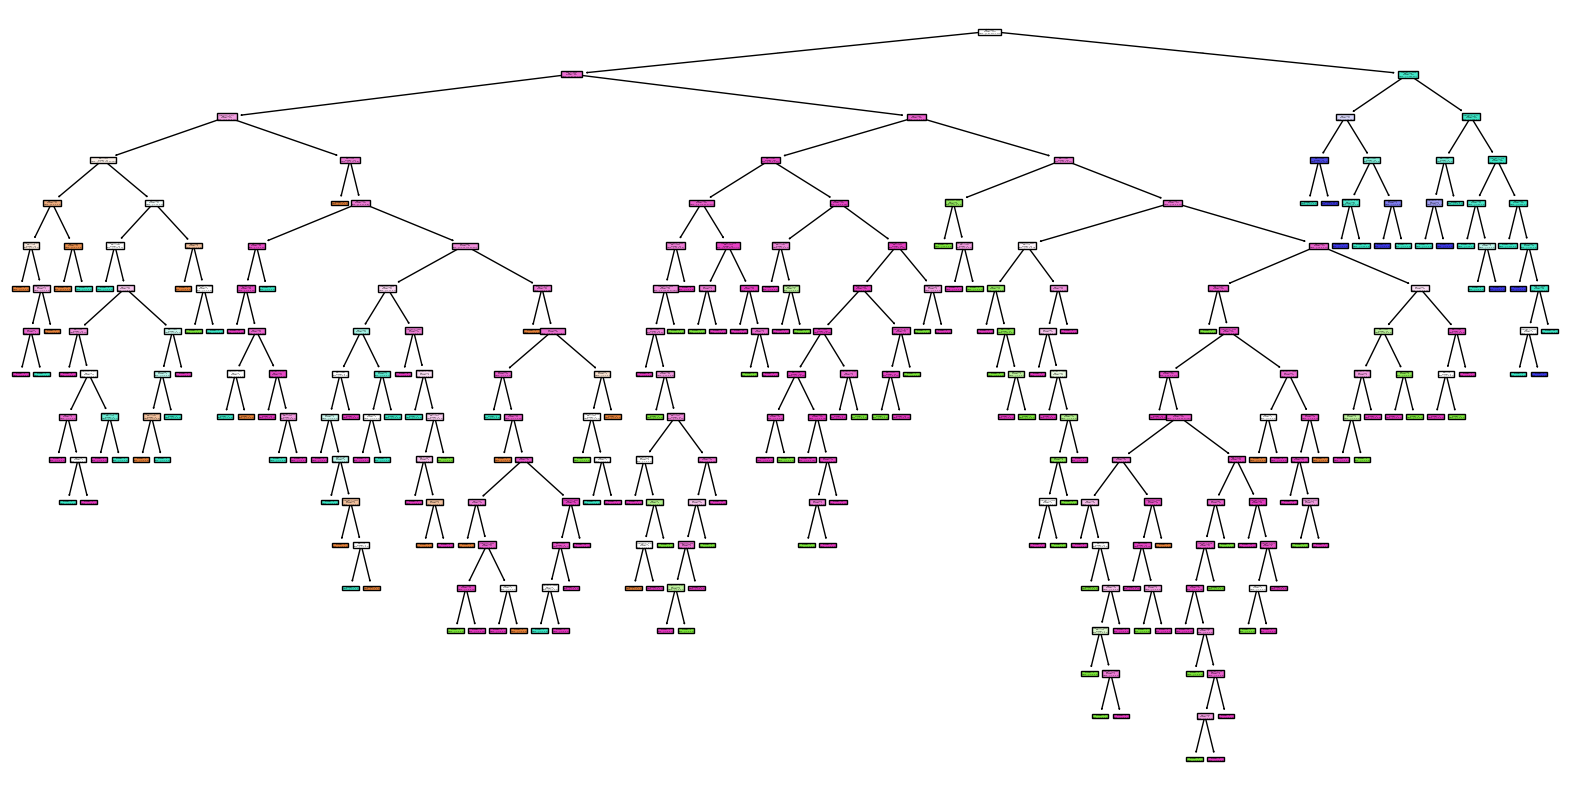

In [92]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns
)

plt.show()

The Decision Tree classifier achieved an accuracy of 78.50% on the test dataset. The model classified weather conditions by creating hierarchical decision rules based on meteorological features. Although the model was easy to interpret, its performance was slightly lower than Logistic Regression, indicating possible overfitting and reduced generalization capability.

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8361774744027304


In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))


              precision    recall  f1-score   support

           0       0.14      0.09      0.11        11
           1       0.70      0.35      0.47        20
           2       0.93      0.94      0.93       129
           3       1.00      0.20      0.33         5
           4       0.79      0.90      0.84       128

    accuracy                           0.84       293
   macro avg       0.71      0.50      0.54       293
weighted avg       0.83      0.84      0.82       293



In [95]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

         Feature  Importance
1  precipitation    0.453961
8      temp_diff    0.111798
0           date    0.098985
2       temp_max    0.095971
3       temp_min    0.071241
4           wind    0.064148
7            day    0.049562
6          month    0.032521
5           year    0.021814


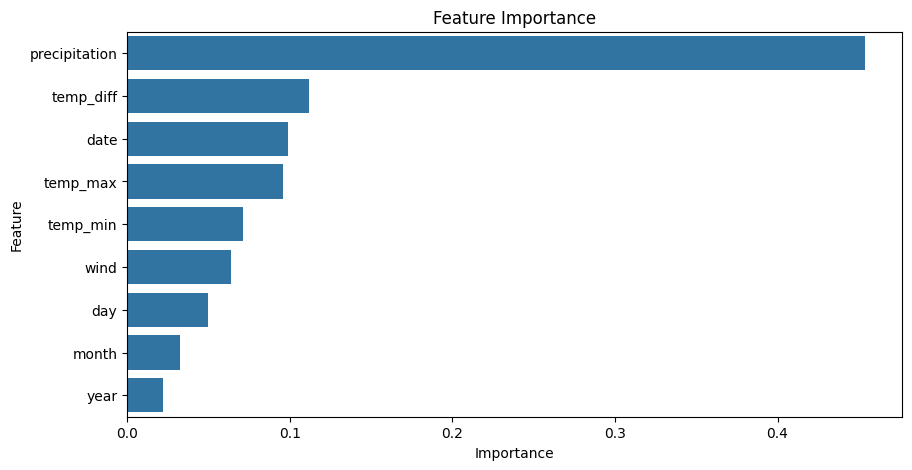

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [98]:
RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [99]:
KNeighborsClassifier(n_neighbors=5)

KNeighborsClassifier()

In [100]:
KNeighborsClassifier(n_neighbors=9)

KNeighborsClassifier(n_neighbors=9)

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(model, X, y, cv=5)
print(scores)
print("Mean Accuracy:", scores.mean())

[0.10238908 0.43835616 0.8630137  0.67465753 0.51369863]
Mean Accuracy: 0.5184230211791108


In [102]:
RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [103]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

scores = cross_val_score(model, X, y, cv=cv)

print("Scores:", scores)
print("Mean:", scores.mean())
print("Std Dev:", scores.std())

Scores: [0.85324232 0.84931507 0.85958904 0.87671233 0.8869863 ]
Mean: 0.865169012109028
Std Dev: 0.014380346588089052


In [104]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [105]:
print(X.columns)

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'year',
       'month', 'day', 'temp_diff'],
      dtype='object')


In [106]:
print(X.shape)

(1461, 9)


In [107]:
import os
print(os.listdir("../input"))

['datasets']


In [108]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [109]:
print(df.columns)

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather',
       'year', 'month', 'day', 'temp_diff'],
      dtype='object')


In [110]:
X = df.drop("weather", axis=1)
y = df["weather"]

In [113]:
import joblib

joblib.dump(model, "model.pkl")


['model.pkl']

In [114]:
import joblib

# save model
joblib.dump(model, "model.pkl")

# save feature names
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [125]:
import joblib

# after training your model
joblib.dump(model, "model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [126]:
import joblib

model = joblib.load("model.pkl")
print("Model loaded successfully")

Model loaded successfully


In [127]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [128]:
from IPython.display import FileLink
FileLink("model.pkl")

/kaggle/working/model.pkl

In [129]:
import os
print(os.path.getsize("model.pkl"))

819


In [130]:
import os
print(os.path.getsize("model.pkl"))


819


In [132]:
import os
print(os.path.getsize("model.pkl"))

819


In [133]:
import os
print(os.path.getsize("model.pkl"))

819


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv
/kaggle/input/datasets/annapoorani13/weather/weather.ipynb


In [4]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv"
)

print(df.head())
print(df.columns)
print(df["weather"].unique())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')
['drizzle' 'rain' 'sun' 'snow' 'fog']


In [5]:
import joblib
from sklearn.ensemble import RandomForestClassifier

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["temp_diff"] = df["temp_max"] - df["temp_min"]

X = df[
    [
        "precipitation",
        "temp_max",
        "temp_min",
        "wind",
        "year",
        "month",
        "day",
        "temp_diff"
    ]
]

y = df["weather"]

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X, y)

joblib.dump(model, "model.pkl")

print("✅ Model saved successfully!")
print("Classes:", model.classes_)

✅ Model saved successfully!
Classes: ['drizzle' 'fog' 'rain' 'snow' 'sun']


In [6]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv"
)

# Feature Engineering
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df["temp_diff"] = df["temp_max"] - df["temp_min"]

# Features
X = df[
    [
        "precipitation",
        "temp_max",
        "temp_min",
        "wind",
        "year",
        "month",
        "day",
        "temp_diff"
    ]
]

# Target
y = df["weather"]

# Model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Train
model.fit(X, y)

# Save
joblib.dump(model, "model.pkl")

print("✅ Model saved successfully!")
print("Classes:", model.classes_)

✅ Model saved successfully!
Classes: ['drizzle' 'fog' 'rain' 'snow' 'sun']


In [7]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv"
)

print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [8]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/mahdiehhajian/seattle-weather/seattle-weather.csv"
)

print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [12]:
print(df.columns)

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')


In [13]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df["temp_diff"] = df["temp_max"] - df["temp_min"]

print(df.columns)

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather',
       'year', 'month', 'day', 'temp_diff'],
      dtype='object')


In [14]:
import joblib
from sklearn.ensemble import RandomForestClassifier

X = df[
    [
        "precipitation",
        "temp_max",
        "temp_min",
        "wind",
        "year",
        "month",
        "day",
        "temp_diff"
    ]
]

y = df["weather"]

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X, y)

print("Features:", model.n_features_in_)
print("Classes:", model.classes_)

joblib.dump(model, "model.pkl")

print("✅ model.pkl saved")

Features: 8
Classes: ['drizzle' 'fog' 'rain' 'snow' 'sun']
✅ model.pkl saved


In [15]:
print(df.columns)

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather',
       'year', 'month', 'day', 'temp_diff'],
      dtype='object')


In [16]:
import joblib
from sklearn.ensemble import RandomForestClassifier

X = df[
    [
        "precipitation",
        "temp_max",
        "temp_min",
        "wind",
        "year",
        "month",
        "day",
        "temp_diff"
    ]
]

y = df["weather"]

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X, y)

print("Features:", model.n_features_in_)
print("Classes:", model.classes_)

joblib.dump(model, "model.pkl")

print("✅ model.pkl saved successfully")

Features: 8
Classes: ['drizzle' 'fog' 'rain' 'snow' 'sun']
✅ model.pkl saved successfully
